In [1]:
"""
================================
Select Electrodes and Resampling
================================

Within paradigm, it is possible to restrict analysis only to a subset of
electrodes and to resample to a specific sampling rate. There is also a
utility function to select common electrodes shared between datasets.
This tutorial demonstrates how to use this functionality.
"""

# Authors: Sylvain Chevallier <sylvain.chevallier@uvsq.fr>
#
# License: BSD (3-clause)
import matplotlib.pyplot as plt
from mne.decoding import CSP
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression as LR
from sklearn.pipeline import make_pipeline

import moabb.analysis.plotting as moabb_plt
from moabb.datasets import BNCI2014_001, Zhou2016
from moabb.datasets.utils import find_intersecting_channels
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import LeftRightImagery



In [2]:

##############################################################################
# Datasets
# --------
#
# Load 2 subjects of BNCI 2014-004 and Zhou2016 datasets, with 2 sessions each

subj = [1, 2]
datasets = [Zhou2016(), BNCI2014_001()]
for d in datasets:
    d.subject_list = subj

In [3]:
##############################################################################
# Paradigm
# --------
#
# Restrict further analysis to specified channels, here C3, C4, and Cz.
# Also, use a specific resampling. In this example, all datasets are
# set to 200 Hz.

paradigm = LeftRightImagery(channels=["C3", "C4", "Cz"], resample=200.0)

In [6]:
##############################################################################
# Evaluation
# ----------
#
# The evaluation is conducted on with CSP+LDA, only on the 3 electrodes, with
# a sampling rate of 200 Hz.

evaluation = WithinSessionEvaluation(paradigm=paradigm, datasets=datasets)
csp_lda = make_pipeline(CSP(n_components=2), LDA())
ts_lr = make_pipeline(
    Covariances(estimator="oas"), TangentSpace(metric="riemann"), LR(C=1.0)
)
results = evaluation.process({"csp+lda": csp_lda, "ts+lr": ts_lr})
print(results.head())

BNCI2014-001-WithinSession: 100%|██████████| 2/2 [00:00<00:00,  8.77it/s]


      score      time  samples subject session  channels  n_sessions  \
0  0.862121  0.016999    119.0       1       0         3           3   
1  0.884000  0.014302    100.0       1       1         3           3   
2  0.938000  0.014527    100.0       1       2         3           3   
3  0.936000  0.014323    100.0       2       0         3           3   
4  0.839506  0.013483     90.0       2       1         3           3   

    dataset pipeline  
0  Zhou2016  csp+lda  
1  Zhou2016  csp+lda  
2  Zhou2016  csp+lda  
3  Zhou2016  csp+lda  
4  Zhou2016  csp+lda  


In [7]:
##############################################################################
# Electrode Selection
# -------------------
#
# It is possible to select the electrodes that are shared by all datasets
# using the `find_intersecting_channels` function. Datasets that have 0
# overlap with others are discarded. It returns the set of common channels,
# as well as the list of datasets with valid channels.

electrodes, datasets = find_intersecting_channels(datasets)
evaluation = WithinSessionEvaluation(
    paradigm=paradigm, datasets=datasets, overwrite=True, suffix="resample"
)
results = evaluation.process({"csp+lda": csp_lda, "ts+lr": ts_lr})
print(results.head())

Extracting EDF parameters from /Users/sopsahl/mne_data/MNE-BIDS-zhou2016/sub-1/ses-0/eeg/sub-1_ses-0_task-imagery_run-0_desc-975305b80f8ef1ae6b60536eec26dff2_eeg.edf...


Setting channel info structure...
Creating raw.info structure...
Reading events from /Users/sopsahl/mne_data/MNE-BIDS-zhou2016/sub-1/ses-0/eeg/sub-1_ses-0_task-imagery_run-0_desc-975305b80f8ef1ae6b60536eec26dff2_events.tsv.
Reading channel info from /Users/sopsahl/mne_data/MNE-BIDS-zhou2016/sub-1/ses-0/eeg/sub-1_ses-0_task-imagery_run-0_desc-975305b80f8ef1ae6b60536eec26dff2_channels.tsv.
Reading electrode coords from /Users/sopsahl/mne_data/MNE-BIDS-zhou2016/sub-1/ses-0/eeg/sub-1_ses-0_space-CapTrak_electrodes.tsv.
Not fully anonymizing info - keeping his_id, sex, and hand info
Reading 0 ... 305249  =      0.000 ...  1220.996 secs...
Extracting EDF parameters from /Users/sopsahl/mne_data/MNE-BIDS-zhou2016/sub-1/ses-0/eeg/sub-1_ses-0_task-imagery_run-1_desc-975305b80f8ef1ae6b60536eec26dff2_eeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading events from /Users/sopsahl/mne_data/MNE-BIDS-zhou2016/sub-1/ses-0/eeg/sub-1_ses-0_task-imagery_run-1_desc-975305b80f

Zhou2016-WithinSession:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting EDF parameters from /Users/sopsahl/mne_data/MNE-BIDS-zhou2016/sub-1/ses-0/eeg/sub-1_ses-0_task-imagery_run-0_desc-975305b80f8ef1ae6b60536eec26dff2_eeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading events from /Users/sopsahl/mne_data/MNE-BIDS-zhou2016/sub-1/ses-0/eeg/sub-1_ses-0_task-imagery_run-0_desc-975305b80f8ef1ae6b60536eec26dff2_events.tsv.
Reading channel info from /Users/sopsahl/mne_data/MNE-BIDS-zhou2016/sub-1/ses-0/eeg/sub-1_ses-0_task-imagery_run-0_desc-975305b80f8ef1ae6b60536eec26dff2_channels.tsv.
Reading electrode coords from /Users/sopsahl/mne_data/MNE-BIDS-zhou2016/sub-1/ses-0/eeg/sub-1_ses-0_space-CapTrak_electrodes.tsv.
Not fully anonymizing info - keeping his_id, sex, and hand info
Reading 0 ... 305249  =      0.000 ...  1220.996 secs...
Extracting EDF parameters from /Users/sopsahl/mne_data/MNE-BIDS-zhou2016/sub-1/ses-0/eeg/sub-1_ses-0_task-imagery_run-1_desc-975305b80f8ef1ae6b60536eec26dff2_eeg.edf...
Setting channel info

Zhou2016-WithinSession:  50%|█████     | 1/2 [00:01<00:01,  1.98s/it]

...

Computing rank from data with rank=None
    Using tolerance 1.5 (2.2e-16 eps * 3 dim * 2.3e+15  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.5 (2.2e-16 eps * 3 dim * 2.3e+15  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.5 (2.2e-16 eps * 3 dim * 2.3e+15  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=

BNCI2014-001-WithinSession:  50%|█████     | 1/2 [00:02<00:02,  2.75s/it]

Computing rank from data with rank=None
    Using tolerance 1.7 (2.2e-16 eps * 3 dim * 2.6e+15  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.8 (2.2e-16 eps * 3 dim * 2.6e+15  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1.8 (2.2e-16 eps * 3 dim * 2.6e+15  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=

BNCI2014-001-WithinSession: 100%|██████████| 2/2 [00:05<00:00,  2.70s/it]


      score      time  samples subject session  channels  n_sessions  \
0  0.854419  0.019624    119.0       1       0         3           3   
1  0.894000  0.017302    100.0       1       1         3           3   
2  0.946000  0.015997    100.0       1       2         3           3   
3  0.934000  0.014291    100.0       2       0         3           3   
4  0.841975  0.017939     90.0       2       1         3           3   

    dataset pipeline  
0  Zhou2016  csp+lda  
1  Zhou2016  csp+lda  
2  Zhou2016  csp+lda  
3  Zhou2016  csp+lda  
4  Zhou2016  csp+lda  


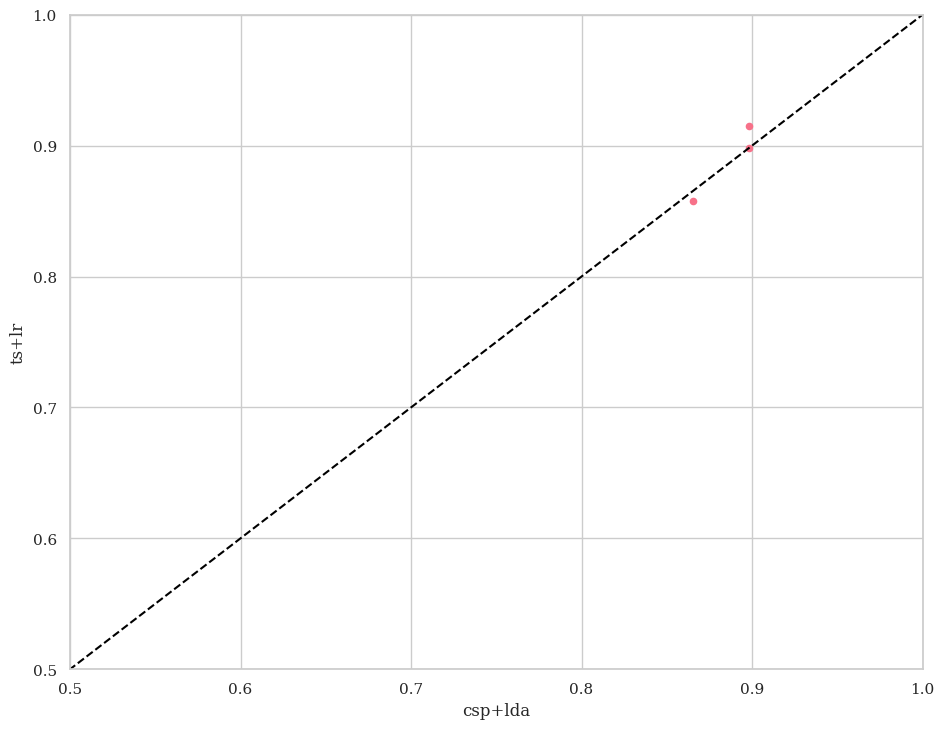

In [8]:
##############################################################################
# Plot Results
# ------------
#
# Compare the obtained results with the two pipelines, CSP+LDA and logistic
# regression computed in the tangent space of the covariance matrices.

fig = moabb_plt.paired_plot(results, "csp+lda", "ts+lr")
plt.show()
